# 🚀 Detector de Deepfakes: Ultra-Optimizado con YOLO y PyTorch (CUDA 12.8)

¡Bienvenido al mundo del **Machine Learning** de alto rendimiento!
Este entorno está configurado para aprovechar al máximo tu:
- 🧠 **AMD Ryzen 7 780M** (para procesamiento y DataLoaders)
- 🏎️ **NVIDIA RTX 5060 Laptop GPU** (VRAM 8GB, Arquitectura Blackwell sm_120)

Vamos a utilizar **Ultralytics (YOLO)** por su insuperable velocidad y API minimalista, para realizar una tarea de **Clasificación de Imágenes** (`Real` vs `Fake`).

**Pre-requisito**: Selecciona un Kernel de Python **3.11**.

## 1. Instalación del Ecosistema Optimo para GPU RTX Serie 5000

Dado que usas una tarjeta serie 5000 (Blackwell), PyTorch regular (2.6.0) arrojará error de compatibilidad. Esta celda se encargará de configurar PyTorch Nightly con soporte para tu nueva arquitectura mediante **CUDA 12.8**.

In [3]:
import sys
import subprocess

def install_packages():
    print("⌛ Limpiando instalaciones previas de PyTorch...")
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
    
    print("⌛ Instalando PyTorch Nightly Experimental para RTX 5000 (CUDA 12.8)...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--pre", "torch", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/nightly/cu128"
    ])
    
    print("⌛ Instalando Librerías de ML Avanzadas...")
    packages = [
        "ultralytics>=8.3.0", 
        "timm>=1.0.0", 
        "albumentations>=1.4.0", 
        "opencv-python-headless>=4.10.0", 
        "Pillow>=10.2.0", 
        "matplotlib>=3.9.0", 
        "tensorboard>=2.17.0", 
        "numpy<2.0.0"
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages)
    print("✅ ¡Ecosistema instalado con éxito!")

# Ejecuta esta celda y espera a que acabe el Output. Una vez termine, ¡REINICIA EL KERNEL!
# install_packages()  # Comentado asumiendo que ya se hizo

## 2. Verificación de Hardware y CUDA

In [4]:
import torch
import torchvision
from ultralytics import YOLO

print("=========================================")
print(f"🔥 PyTorch Versión: {torch.__version__}")
print(f"🔥 Torchvision Versión: {torchvision.__version__}")
print(f"🔥 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"🔥 GPU Detectada: {device_name}")
    print(f"🔥 VRAM Total: {vram:.2f} GB")
    
    # Test real de kernel (para verificar que CUDA responde correctamente)
    try:
        x = torch.randn(2, 3, 64, 64, device='cuda')
        conv = torch.nn.Conv2d(3, 8, 3, padding=1).to('cuda')
        y = conv(x)
        _ = y.mean().item()
        torch.cuda.synchronize()
        print("✅ Test de compilación y kernel CUDA superado en la GPU")
    except Exception as e:
        print(f"❌ ERROR CUDA Runtime: {e}")
        
print("=========================================")

🔥 PyTorch Versión: 2.12.0.dev20260228+cu128
🔥 Torchvision Versión: 0.26.0.dev20260221+cu128
🔥 CUDA Available: True
🔥 GPU Detectada: NVIDIA GeForce RTX 5060 Laptop GPU
🔥 VRAM Total: 7.96 GB
✅ Test de compilación y kernel CUDA superado en la GPU


## 3. Preparación Rápida del Dataset (Formato YOLO)

YOLO Classification espera carpetas `train` y `val` dentro del directorio del dataset. Si tu carpeta de testeo se llama `test`, haremos un enlace/copia rápido a `val`.

In [5]:
import os
import shutil

DATASET_PATH = r"d:\proyectos\Detector de ia\dataset_deepdetect\ddata"
test_dir = os.path.join(DATASET_PATH, "test")
val_dir = os.path.join(DATASET_PATH, "val")

if not os.path.exists(val_dir) and os.path.exists(test_dir):
    print("🔁 Copiando carpeta 'test' a 'val' para compatibilidad nativa con YOLO...")
    shutil.copytree(test_dir, val_dir)
    print("✅ Copia completada.")
else:
    print("✅ La estructura de carpetas ya está correcta para YOLO.")

print("📦 Clases para Entrenamiento:")
for cls in os.listdir(os.path.join(DATASET_PATH, "train")):
    print(f"  - {cls}")

✅ La estructura de carpetas ya está correcta para YOLO.
📦 Clases para Entrenamiento:
  - fake
  - real


## 4. Entrenamiento del Modelo (La fuerza de la RTX 5060 + Ryzen 7)

Vamos a cargar `yolov8n-cls.pt` (una red pre-entrenada nano para clasificación). YOLO descargará los pesos si no los encuentra.

**Importante para PC con Windows**: Cuando usamos Windows y una GPU dedicada, lanzar un número elevado de `workers` en el DataLoader copia procesos en segundo plano a la memoria RAM. Usaremos `workers=0` obligatoriamente, ya que configuraciones mayores causan el fatídico `CUDNN_STATUS_INTERNAL_ERROR_HOST_ALLOCATION_FAILED` provocado por la falta de manejo eficiente de memoria multi-proceso de Windows.

In [4]:
# 1. Instanciamos el modelo pre-entrenado (Clasificador 'nano')
model = YOLO('yolov8n-cls.pt')  

# 2. Lanzamos el entrenamiento 
print("🚀 ¡Iniciando el motor YOLO!")

results = model.train(
    data=DATASET_PATH,
    epochs=5,
    batch=64,      # Optimizado para VRAM sin ahogarse
    workers=0,     # ESTRICTAMENTE 0: El error previo de Host Allocation confirma que el Multiprocessing de Windows hace crash masivo en memoria.
    cache=False,   # No cacheamos en RAM las imágenes 
    imgsz=224, 
    project='runs_yolo', 
    name='deepfake_det_5060',
    device=0  # Fuerza el uso de la GPU 0 (NVIDIA RTX 5060)
)


🚀 ¡Iniciando el motor YOLO!
Ultralytics 8.4.19  Python-3.11.9 torch-2.12.0.dev20260228+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\proyectos\Detector de ia\dataset_deepdetect\ddata, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deepfake_det_50606, nbs=64, 

## 5. Hacer una Inferencia Rápida (Testear una imagen)
Una vez que el modelo acabe, podemos probarlo en vivo.

🖼️ Imagen seleccionada: d:\proyectos\Detector de ia\dataset_deepdetect\ddata\val\fake\fake_044859.jpg


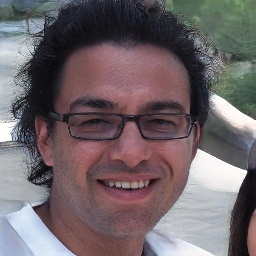

✅ Modelos detectados: 2
✅ Usando el más reciente: d:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt

image 1/1 d:\proyectos\Detector de ia\dataset_deepdetect\ddata\val\fake\fake_044859.jpg: 224x224 fake 1.00, real 0.00, 47.7ms
Speed: 5.9ms preprocess, 47.7ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

--- RESULTADOS ---
fake: 0.9999
real: 0.0001

🏁 Predicción final: FAKE (99.99%)


In [10]:
import glob
import random
import os
from IPython.display import display, Image as IPyImage

def find_latest_yolo_best_model():
    candidates = []

    # 1) Intento directo desde la sesión actual (si hoy sí hubo entrenamiento)
    if 'results' in globals():
        save_dir = str(getattr(results, 'save_dir', ''))
        if save_dir:
            p = os.path.join(save_dir, 'weights', 'best.pt')
            if os.path.exists(p):
                candidates.append(p)

    # 2) Búsqueda en corridas previas del proyecto
    search_patterns = [
        os.path.join(os.getcwd(), 'runs', 'classify', 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs', 'classify', '*', 'weights', 'best.pt'),
    ]

    for pattern in search_patterns:
        candidates.extend(glob.glob(pattern))

    # Quitar duplicados conservando orden
    unique_candidates = list(dict.fromkeys(candidates))

    # Filtrar rutas válidas y ordenar por fecha de modificación (más reciente primero)
    valid_candidates = [p for p in unique_candidates if os.path.isfile(p)]
    valid_candidates.sort(key=os.path.getmtime, reverse=True)

    if not valid_candidates:
        return None, []
    return valid_candidates[0], valid_candidates

# -------- Validaciones previas --------
if 'DATASET_PATH' not in globals():
    print("❌ Falta DATASET_PATH. Ejecuta primero la celda 3 (preparación del dataset).")
elif 'YOLO' not in globals():
    print("❌ Falta YOLO. Ejecuta primero la celda 2 (imports y verificación CUDA).")
else:
    # 1. Buscar imágenes de prueba en val/fake
    fake_dir = os.path.join(DATASET_PATH, "val", "fake")
    patterns = ["*.jpg", "*.jpeg", "*.png", "*.webp"]
    fake_images = []
    for p in patterns:
        fake_images.extend(glob.glob(os.path.join(fake_dir, p)))

    if not fake_images:
        print(f"❌ No se encontraron imágenes en: {fake_dir}")
        print("TIP: Verifica que exista la carpeta val/fake y que tenga archivos .jpg/.jpeg/.png/.webp")
    else:
        # 2. Selección aleatoria y visualización
        test_img = random.choice(fake_images)
        print(f"🖼️ Imagen seleccionada: {test_img}")
        display(IPyImage(filename=test_img, width=224))

        # 3. Localizar mejor modelo (entrenamiento actual o previo)
        best_model_path, found_models = find_latest_yolo_best_model()

        if best_model_path is None:
            print("❌ No se encontró ningún archivo best.pt en las corridas de YOLO.")
            print("TIP: Revisa estas rutas: runs/classify/runs_yolo/*/weights/best.pt")
        else:
            print(f"✅ Modelos detectados: {len(found_models)}")
            print(f"✅ Usando el más reciente: {best_model_path}")

            # 4. Cargar modelo y predecir
            my_model = YOLO(best_model_path)
            results_inference = my_model(test_img)

            # 5. Mostrar resultados
            print("\n--- RESULTADOS ---")
            res0 = results_inference[0]
            probs = getattr(res0, 'probs', None)

            if probs is None:
                print("⚠️ El resultado no contiene probabilidades (probs).")
            else:
                for i, name in res0.names.items():
                    score = float(probs.data[i])
                    print(f"{name}: {score:.4f}")

                top_idx = int(probs.top1)
                top_label = res0.names[top_idx]
                top_conf = float(probs.top1conf)
                print(f"\n🏁 Predicción final: {top_label.upper()} ({top_conf:.2%})")

✅ Usando modelo: d:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt

image 1/1 C:\Users\marce\Pictures\Screenshots\pa.jpg: 224x224 real 1.00, fake 0.00, 6.3ms
Speed: 12.4ms preprocess, 6.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


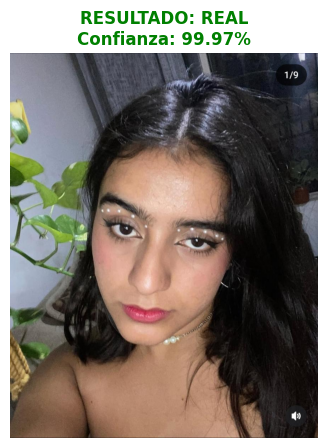

✅ VERIFICADO: El modelo identifica esta imagen como auténtica.


In [22]:
import os
import glob
import PIL.Image
import matplotlib.pyplot as plt

def find_latest_yolo_best_model():
    candidates = []

    if 'results' in globals():
        save_dir = str(getattr(results, 'save_dir', ''))
        if save_dir:
            p = os.path.join(save_dir, 'weights', 'best.pt')
            if os.path.exists(p):
                candidates.append(p)

    search_patterns = [
        os.path.join(os.getcwd(), 'runs', 'classify', 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs', 'classify', '*', 'weights', 'best.pt'),
    ]
    for pattern in search_patterns:
        candidates.extend(glob.glob(pattern))

    unique_candidates = list(dict.fromkeys(candidates))
    valid_candidates = [p for p in unique_candidates if os.path.isfile(p)]
    valid_candidates.sort(key=os.path.getmtime, reverse=True)

    if not valid_candidates:
        return None
    return valid_candidates[0]

# --- PRUEBA TU PROPIA IMAGEN ---
# Cambia esta ruta por la de tu imagen (ejemplo: r"C:\Descargas\cara_ai.jpg")
RUTA_IMAGEN_EXTERNA = r"C:\Users\marce\Pictures\Screenshots\pa.jpg"

if 'YOLO' not in globals():
    print("❌ Falta YOLO. Ejecuta primero la celda 2 (imports y verificación CUDA).")
elif os.path.exists(RUTA_IMAGEN_EXTERNA):
    best_model_path = find_latest_yolo_best_model()

    if best_model_path is None:
        print("❌ No se encontró ningún best.pt en corridas previas de YOLO.")
        print("TIP: Ejecuta entrenamiento o verifica runs/classify/runs_yolo/*/weights/best.pt")
    else:
        print(f"✅ Usando modelo: {best_model_path}")
        my_model = YOLO(best_model_path)

        # Predecir
        res = my_model(RUTA_IMAGEN_EXTERNA)[0]
        top_label = res.names[int(res.probs.top1)]
        conf = float(res.probs.top1conf)

        # Mostrar resultado
        img = PIL.Image.open(RUTA_IMAGEN_EXTERNA)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        color = "red" if top_label == "fake" else "green"
        plt.title(f"RESULTADO: {top_label.upper()}\nConfianza: {conf:.2%}", color=color, fontweight='bold')
        plt.axis('off')
        plt.show()

        if top_label == "fake":
            print("⚠️ ALERTA: Esta imagen parece haber sido manipulada o generada por IA.")
        else:
            print("✅ VERIFICADO: El modelo identifica esta imagen como auténtica.")
else:
    print("❌ Error: No se encontró ningún archivo en la ruta especificada.")
    print("TIP: Asegúrate de poner la 'r' antes de las comillas en la ruta en Windows.")

## 6. Clasificación desde URL (recorte de rostros + visualización completa)

Esta celda descarga una imagen desde internet, detecta los rostros con un detector ligero (`yolov8n-face.pt`), recorta cada cara y clasifica cada recorte con tu modelo de deepfakes (`best.pt`).

- Entrada: URL de imagen
- Detector de rostros: YOLO nano (ligero)
- Clasificador: tu mejor modelo entrenado encontrado automáticamente
- Salida visual: imagen original con cajas + mosaico de rostros recortados y su predicción

✅ Clasificador: d:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt
🌐 Imagen descargada: 1920x1080
✅ Detector de rostro activo: opencv-haar
✅ Rostros evaluados: 2


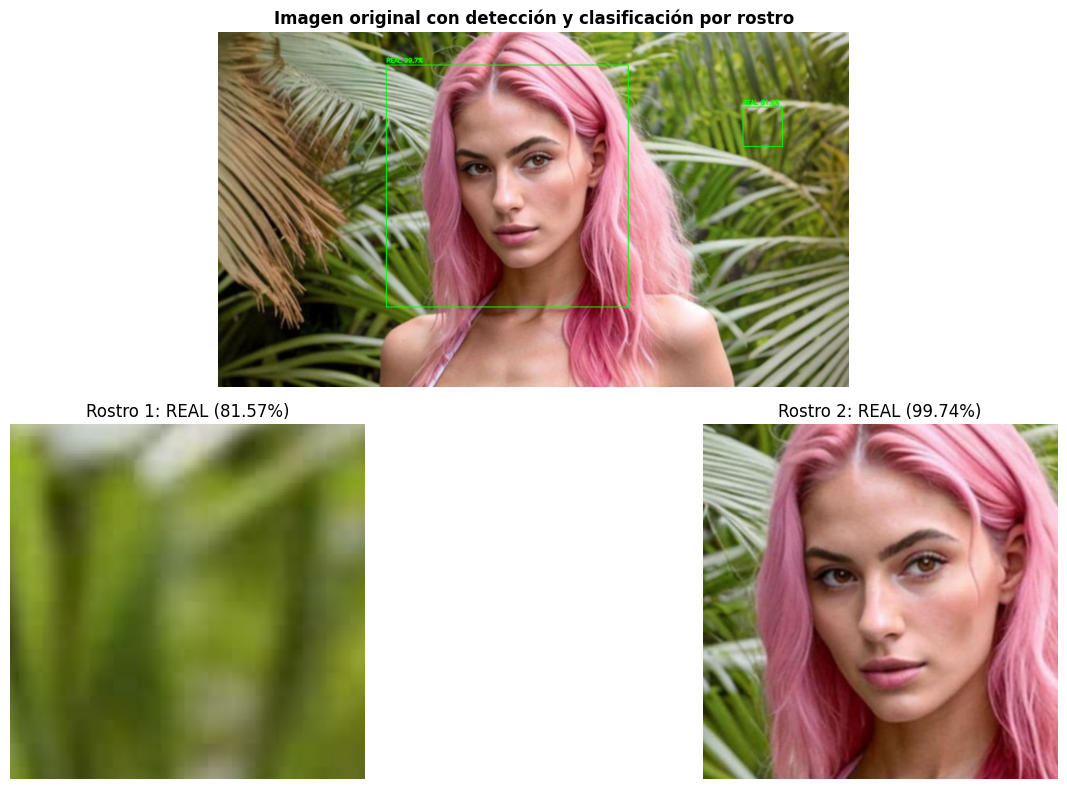

In [23]:
import os
import glob
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ===========================
# Configuración de la prueba
# ===========================
URL_IMAGEN = "https://www.hola.com/us/horizon/landscape/76c536e7e944-aitana-lopez.jpg"  # cambia por cualquier URL directa
FACE_MODEL_PATH = r"d:\proyectos\Detector de ia\yolov8n-face.pt"
MARGIN_RATIO = 0.20  # margen alrededor del rostro para parecerse a retratos cercanos
MAX_IMAGE_SIDE = 1920  # reduce imágenes muy grandes para acelerar detección

def find_latest_yolo_best_model():
    candidates = []

    if 'results' in globals():
        save_dir = str(getattr(results, 'save_dir', ''))
        if save_dir:
            p = os.path.join(save_dir, 'weights', 'best.pt')
            if os.path.exists(p):
                candidates.append(p)

    search_patterns = [
        os.path.join(os.getcwd(), 'runs', 'classify', 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs_yolo', '*', 'weights', 'best.pt'),
        os.path.join(os.getcwd(), 'runs', 'classify', '*', 'weights', 'best.pt'),
    ]
    for pattern in search_patterns:
        candidates.extend(glob.glob(pattern))

    unique_candidates = list(dict.fromkeys(candidates))
    valid_candidates = [p for p in unique_candidates if os.path.isfile(p)]
    valid_candidates.sort(key=os.path.getmtime, reverse=True)
    return valid_candidates[0] if valid_candidates else None

def read_image_from_url(url: str):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=20) as response:
        image_bytes = response.read()
    image_array = np.frombuffer(image_bytes, dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError("No se pudo decodificar la imagen desde la URL.")
    return img_bgr

def maybe_resize(img_bgr, max_side=1920):
    h, w = img_bgr.shape[:2]
    side = max(h, w)
    if side <= max_side:
        return img_bgr
    scale = max_side / float(side)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

def expand_box(x1, y1, x2, y2, w, h, margin_ratio=0.2):
    bw, bh = x2 - x1, y2 - y1
    mx, my = int(bw * margin_ratio), int(bh * margin_ratio)
    nx1, ny1 = max(0, x1 - mx), max(0, y1 - my)
    nx2, ny2 = min(w - 1, x2 + mx), min(h - 1, y2 + my)
    return nx1, ny1, nx2, ny2

def load_face_detector(face_model_path):
    if os.path.exists(face_model_path):
        try:
            detector = YOLO(face_model_path)
            return "yolo-face", detector
        except Exception as e:
            print(f"⚠️ No se pudo cargar {face_model_path}: {e}")
            print("↪️ Fallback: usaré detector frontal de OpenCV (ligero).")

    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    cascade = cv2.CascadeClassifier(cascade_path)
    if cascade.empty():
        raise RuntimeError("No se pudo inicializar haarcascade_frontalface_default.xml")
    return "opencv-haar", cascade

def detect_faces(img_bgr, detector_kind, detector_obj):
    if detector_kind == "yolo-face":
        det = detector_obj.predict(source=img_bgr, conf=0.25, verbose=False)[0]
        boxes = det.boxes
        if boxes is None or len(boxes) == 0:
            return []
        out = []
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int).tolist()
            out.append((x1, y1, x2, y2))
        return out

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = detector_obj.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    return [(int(x), int(y), int(x + w), int(y + h)) for (x, y, w, h) in faces]

# =========
# Pipeline
# =========
best_model_path = find_latest_yolo_best_model()
if best_model_path is None:
    print("❌ No se encontró ningún best.pt para clasificación.")
    print("TIP: Debe existir algo como runs/classify/runs_yolo/*/weights/best.pt")
else:
    print(f"✅ Clasificador: {best_model_path}")

    try:
        img_bgr = read_image_from_url(URL_IMAGEN)
        original_h, original_w = img_bgr.shape[:2]
        img_bgr = maybe_resize(img_bgr, max_side=MAX_IMAGE_SIDE)
        h, w = img_bgr.shape[:2]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        print(f"🌐 Imagen descargada: {original_w}x{original_h}")
        if (original_w, original_h) != (w, h):
            print(f"⚡ Imagen redimensionada para inferencia: {w}x{h}")
    except Exception as e:
        print(f"❌ Error al descargar/cargar imagen: {e}")
        raise

    detector_kind, face_detector = load_face_detector(FACE_MODEL_PATH)
    print(f"✅ Detector de rostro activo: {detector_kind}")

    clf_model = YOLO(best_model_path)
    raw_boxes = detect_faces(img_bgr, detector_kind, face_detector)

    if not raw_boxes:
        print("⚠️ No se detectaron rostros en la URL indicada.")
        plt.figure(figsize=(8, 8))
        plt.imshow(img_rgb)
        plt.title("Imagen original (sin rostros detectados)")
        plt.axis("off")
        plt.show()
    else:
        faces_info = []
        canvas = img_rgb.copy()

        for i, (x1, y1, x2, y2) in enumerate(raw_boxes, start=1):
            x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, margin_ratio=MARGIN_RATIO)
            face_rgb = img_rgb[y1:y2, x1:x2]
            if face_rgb.size == 0:
                continue

            pred = clf_model.predict(source=face_rgb, verbose=False)[0]
            probs = pred.probs
            if probs is None:
                label = "unknown"
                conf = 0.0
            else:
                top_idx = int(probs.top1)
                label = pred.names[top_idx]
                conf = float(probs.top1conf)

            faces_info.append({
                "bbox": (x1, y1, x2, y2),
                "face_rgb": face_rgb,
                "label": label,
                "conf": conf
            })

            color = (255, 0, 0) if label == "fake" else (0, 255, 0)
            cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                canvas,
                f"{label.upper()} {conf:.1%}",
                (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
                cv2.LINE_AA
            )

        if not faces_info:
            print("⚠️ Se detectaron cajas, pero no se pudieron recortar rostros válidos.")
            plt.figure(figsize=(8, 8))
            plt.imshow(img_rgb)
            plt.title("Imagen original")
            plt.axis("off")
            plt.show()
        else:
            print(f"✅ Rostros evaluados: {len(faces_info)}")

            n = len(faces_info)
            cols = min(4, n)
            rows = int(np.ceil(n / cols))

            fig = plt.figure(figsize=(14, 5 + rows * 3))
            gs = fig.add_gridspec(rows + 1, cols)

            ax0 = fig.add_subplot(gs[0, :])
            ax0.imshow(canvas)
            ax0.set_title("Imagen original con detección y clasificación por rostro", fontsize=12, fontweight='bold')
            ax0.axis("off")

            for idx, info in enumerate(faces_info):
                r = idx // cols + 1
                c = idx % cols
                ax = fig.add_subplot(gs[r, c])
                ax.imshow(info["face_rgb"])
                ax.set_title(f"Rostro {idx+1}: {info['label'].upper()} ({info['conf']:.2%})")
                ax.axis("off")

            plt.tight_layout()
            plt.show()